# Round 1: Australian GP Qualifying Analysis

## Imports and Data Loading

In [107]:
import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fastf1 import plotting
from src.plotset import setup_plot
from src.utils import compute_track_dominance_multi, quali_track_evolution
from src.plotset import plot_track_dominance, plot_quali_track_evolution, save_fig

setup_plot()

Matplotlib rcParams initialized with custom style.


In [2]:
fastf1.Cache.enable_cache('./f1_cache')
fastf1.Cache.get_cache_info()

('./f1_cache', 2157588975)

In [3]:
session = fastf1.get_session(2026, 1, 'Q')
session.load()

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading d

## Track Domination

In [85]:
points, segments, colors = compute_track_dominance_multi(session=session, drivers=['RUS','HAD'], circuit_length=5278, window_size=100)

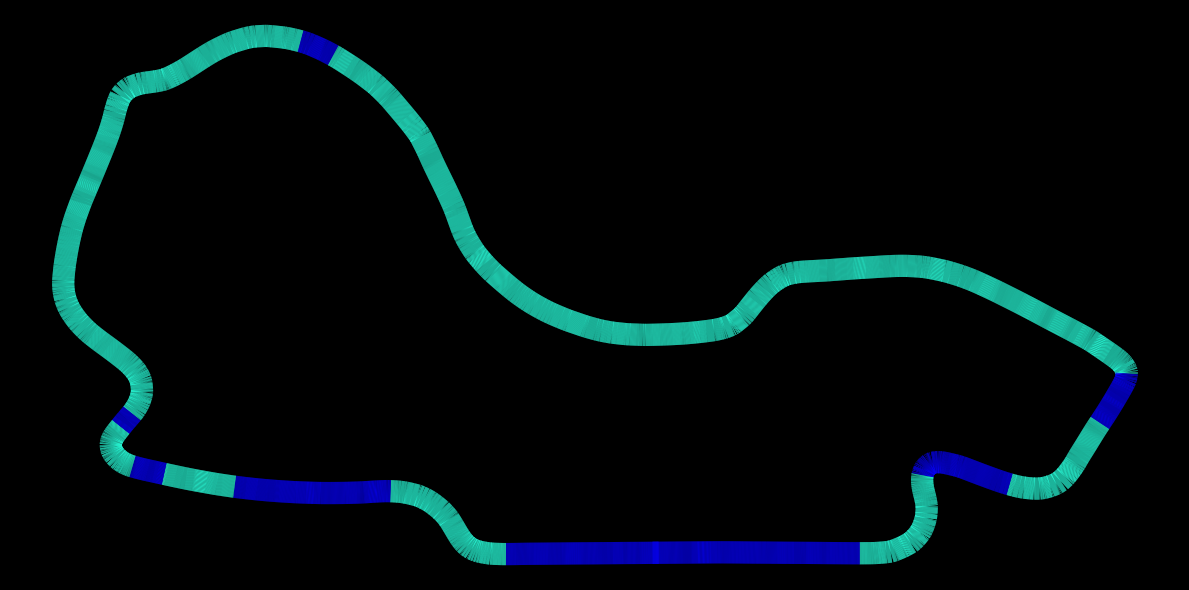

In [112]:
dominance_plot = plot_track_dominance(points, segments, colors, figsize=(12, 6))

In [113]:
save_fig(fig=dominance_plot, name='track_dominance', loc='Reel23', trs=True)

Figure saved at ./media/Reel23/track_dominance.png


## Qualifying Laptime Evolution

In [72]:
df = quali_track_evolution(session=session)

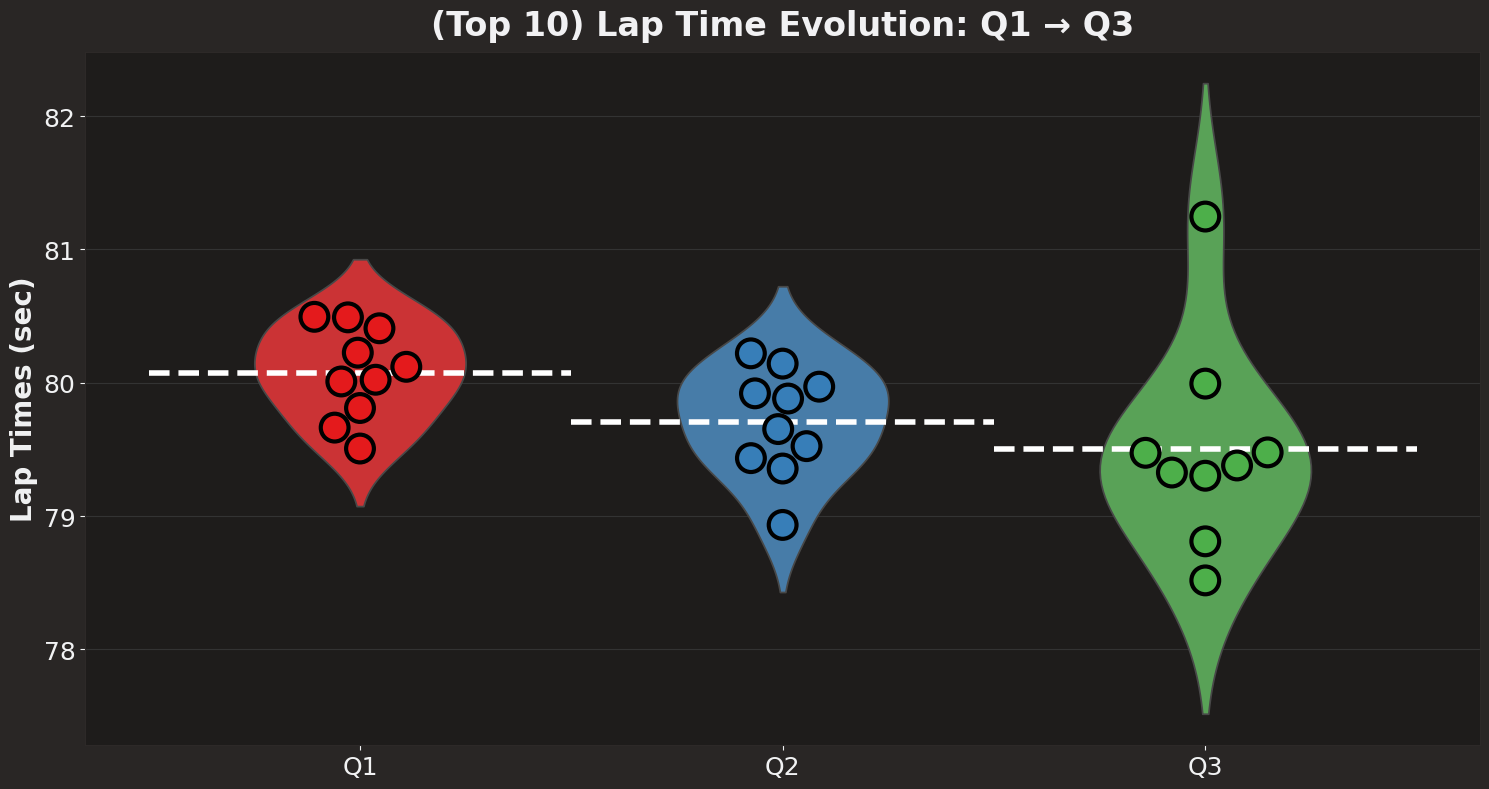

In [109]:
evo = plot_quali_track_evolution(df=df)

In [111]:
save_fig(fig=evo, name='track_evolution', loc='Reel23', trs=True)

Figure saved at ./media/Reel23/track_evolution.png


## Laptime Delta Analysis

In [96]:
corners = session.get_circuit_info().corners
rotation = session.get_circuit_info().rotation

In [88]:
ref_lap = session.laps.pick_drivers('RUS').pick_fastest().get_telemetry().copy()
comp_lap = session.laps.pick_drivers('HAD').pick_fastest().get_telemetry().copy()

In [89]:
mult = ref_lap.Distance.iloc[-1]/comp_lap.Distance.iloc[-1]

ref_dist = ref_lap.Distance.to_numpy()
ref_time = ref_lap.Time.dt.total_seconds().to_numpy()
comp_dist = (comp_lap.Distance * mult).to_numpy()
comp_time = comp_lap.Time.dt.total_seconds().to_numpy()

In [93]:
comp_time = np.interp(ref_dist, comp_dist, comp_time)

In [94]:
delta = comp_time - ref_time

Matplotlib rcParams initialized with custom style.


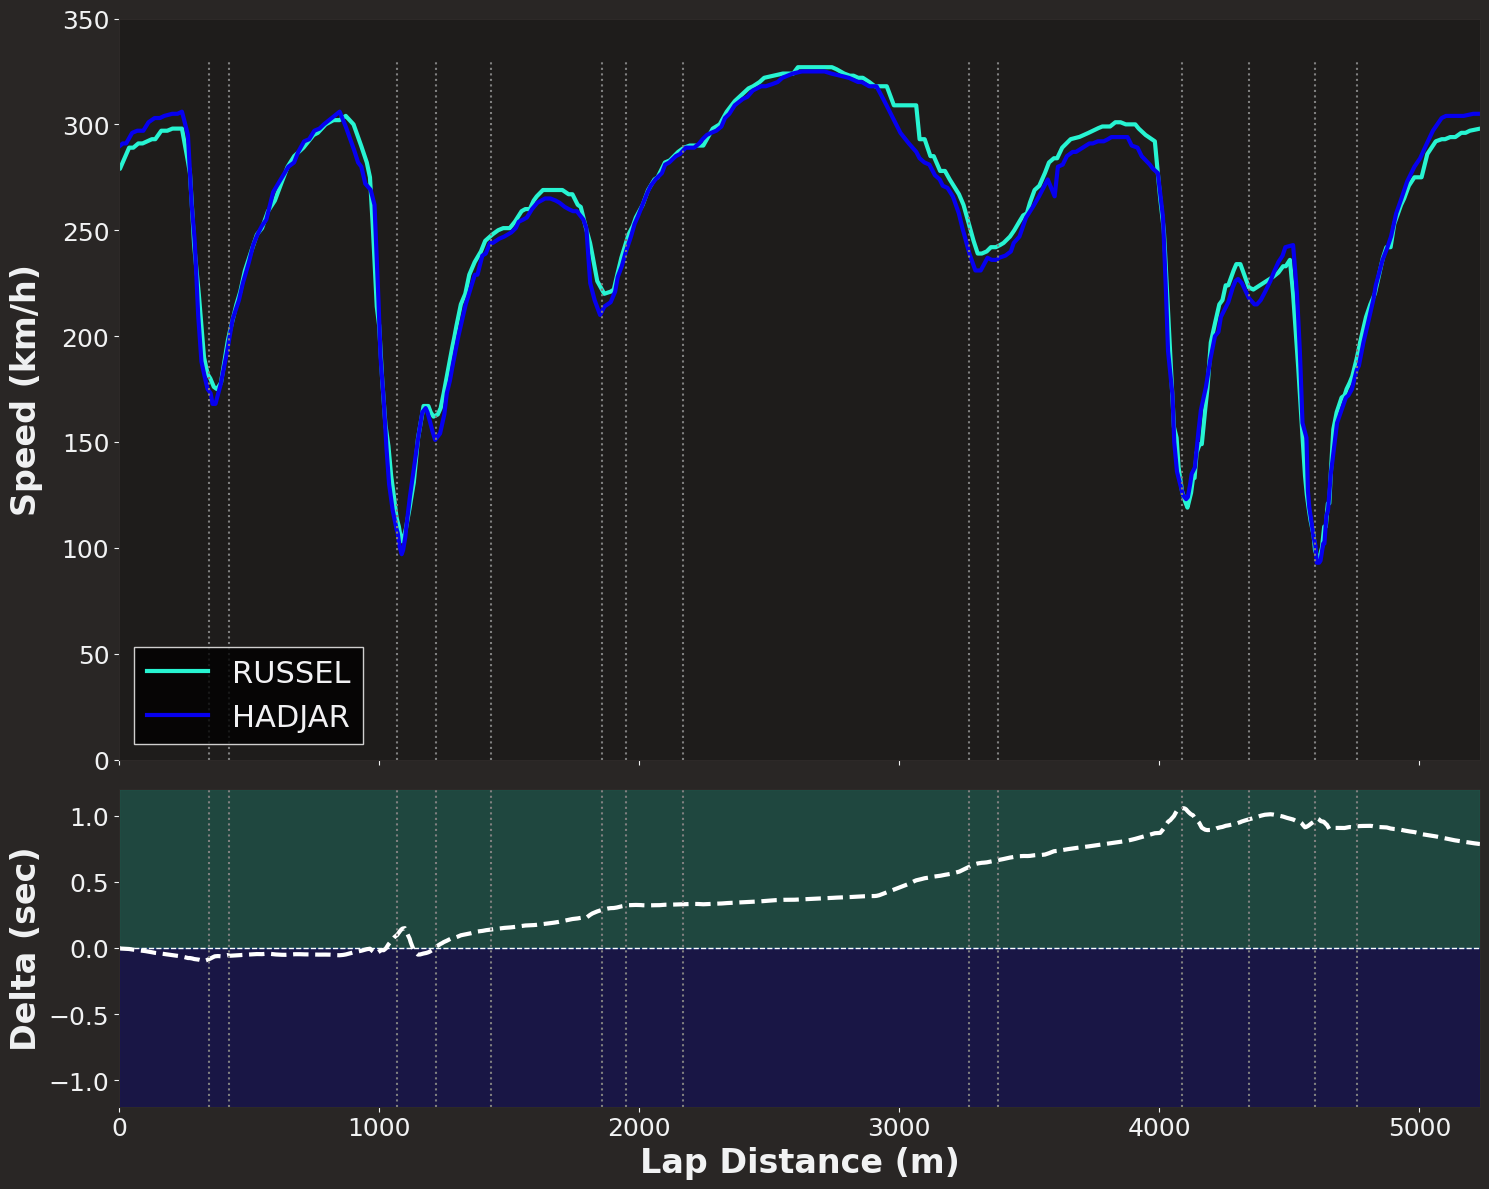

In [118]:
setup_plot(axeslabel=24, figtitle=28, legendfont=22)

rus_color = plotting.get_driver_color(session=session, identifier='RUS')
had_color = plotting.get_driver_color(session=session, identifier='HAD')

fig, ax = plt.subplots(2,1,figsize=(15,12),height_ratios=[0.7,0.3],sharex=True)
ax[0].plot(ref_lap['Distance'],ref_lap['Speed'],color=rus_color,linewidth=3, label='RUSSEL')
ax[0].plot(comp_lap['Distance'],comp_lap['Speed'],color=had_color,linewidth=3, label='HADJAR')

ax[0].vlines(x=corners['Distance'], ymin=0, ymax=330,
          linestyles='dotted', colors='grey')
# for _, corner in corners.iterrows():
#     txt = f"{corner['Number']}{corner['Letter']}"
#     ax[0].text(corner['Distance'], 340, txt,
#             va='center_baseline', ha='center', size=15, color="#00FF0D")

# ax[0].set_title('Speed Trace', pad=30)
ax[0].set_xlim(ref_dist[0],ref_dist[-1])
ax[0].set_ylim(0, 350)
ax[0].set_ylabel('Speed (km/h)')
ax[0].legend()
ax[0].grid(visible=False)
# ax02 = ax[0].twinx()
# ax02.set_yticks([])
# ax02.set_ylabel('BK',color="#292929",labelpad=30)

ax[1].plot(ref_lap['Distance'],delta,ls='--',lw=3,color='w')
ax[1].axhline(y=0,lw=1,ls='--',color="#FFFFFF")

ax[1].vlines(x=corners['Distance'], ymin=-1.2, ymax=1.2,
          linestyles='dotted', colors='grey')

ax[1].fill_between(x=(ref_dist[0],ref_dist[-1]),y1=0,y2=1.2,color=rus_color,alpha=0.2)
ax[1].fill_between(x=(ref_dist[0],ref_dist[-1]),y1=-1.2,y2=0,color=had_color,alpha=0.2)

# ax[1].set_title('Lap Time Delta')
ax[1].set_xlim(ref_dist[0],ref_dist[-1])
ax[1].set_ylim(-1.2,1.2)
ax[1].set_ylabel('Delta (sec)')
ax[1].set_xlabel('Lap Distance (m)')
ax[1].grid(visible=False)

fig.align_labels(axs=ax)

In [119]:
save_fig(fig=fig, name='delta_analysis', loc='Reel23', trs=True)

Figure saved at ./media/Reel23/delta_analysis.png
